# Fig 5: reaction-time prediction

Linear: **SHI-61**. Paper question: *do insula functional clusters predict response speed, and when?*

Single-electrode time-resolved Ridge on strict Hammers AIC/PIC. NMF cluster labels color and group after the fact; they are not model features. Tasks are Repeat in **LexicalDelay, PhonemeSequence, PictureNaming** only; SentenceRep is not in the RT ridge cohort.

Separate SVGs (assemble in Adobe):

1. **Time-resolved prediction** — Delay / Go / Response, each with a $t=0$ line. Rows are Delay + Go hits (same electrodes as the 27-point map); Response is still a column. Top: cluster-mean OOF Pearson $r$ in FWER-significant, $r>0$ windows.
2. **HGA–RT encoding** — Motor is the main three-panel (Go fast/slow HGA, subject $r$, example trial scatter). Sustain / Sensory are supplement. Post-selection descriptive, not an independent confirmatory test.
3. **Hit electrodes (main)** — assigned Delay + Go hits only (27 plotted). The all-phase map including pre-Response is supplement.

A valid window is FWER-significant with OOF $r>0$. A **hit** has at least one such window after Delay onset, before Go, or before Response. Raster HDF5 load is I/O-heavy; encoding panels read CSVs only.

Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md). SVG only.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, wilcoxon

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import CLUSTER_LABELS, CLUSTER_ORDER, FUNCTION_COLORS
from src.paths import RESULTS_ROOT, img_dir, save_svg
from src.reaction_time.insula_rt_io import decode_strings, phase_output_path

In [2]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

fontsize = 7
fontdict = dict(fontsize=fontsize)

DESCRIPTION = "Repeat"
PHASE_ORDER = ["Delay", "Go", "Response"]
PANELS = [
    {
        "key": "Delay",
        "phase": "Delay",
        "xlim": (-1.0, 1.5),
        "xlabel": "Delay (s)",
        "xticks": [-1, 0, 1],
    },
    {
        "key": "Go",
        "phase": "Go",
        "xlim": (-1.0, 1.5),
        "xlabel": "Go (s)",
        "xticks": [-1, 0, 1],
    },
    {
        "key": "Response",
        "phase": "Response",
        "xlim": (-1.0, 1.5),
        "xlabel": "Response (s)",
        "xticks": [-1, 0, 1],
    },
]
# Heatmap / curve stack, top → bottom.
RASTER_CLUSTER_ORDER = ["sensory", "sustain", "motor"]
ENCODING_CLUSTERS = ("motor", "sustain", "sensory")

DELAY_XLIM = (-1.0, 1.5)
GO_XLIM = (-1.0, 1.5)
HGA_XTICKS = (-1.0, 0.0, 1.0)
HGA_YLIM = (0.0, 2.0)

DT = 0.02
SMOOTH_SIGMA = 2.0
TASK_SHORT = {
    "LexicalDelay": "LD",
    "PhonemeSequence": "PS",
    "PictureNaming": "PN",
}

RT_ROOT = RESULTS_ROOT / "rt"
SUMMARY_DIR = RT_ROOT / "summaries"
IMG_DIR = img_dir("fig5")


## Load summaries

Ridge coverage / electrodes / significant clusters from
`python -m src.reaction_time.summarize_insula_rt_ridge`.
Encoding CSVs from `python -m src.reaction_time.summarize_insula_rt_encoding`.

Hit rule matches `docs/RT_RIDGE.md`: Delay `end_time > 0`; Go / Response `start_time < 0`.


In [3]:
def _cluster_label(value):
    if pd.isna(value) or str(value).strip() == "":
        return "unassigned"
    return str(value)


def in_hit_window(row):
    """Cluster overlaps after Delay, before Go, or before Response."""
    if row["phase"] == "Delay":
        return float(row["end_time"]) > 0
    if row["phase"] in {"Go", "Response"}:
        return float(row["start_time"]) < 0
    return False


coverage = pd.read_csv(SUMMARY_DIR / "coverage.csv")
electrodes = pd.read_csv(SUMMARY_DIR / "electrodes.csv")
clusters = pd.read_csv(SUMMARY_DIR / "significant_clusters.csv")

electrodes["functional_cluster"] = electrodes["functional_cluster"].map(_cluster_label)
clusters["functional_cluster"] = clusters["functional_cluster"].map(_cluster_label)
clusters["in_hit_window"] = clusters.apply(in_hit_window, axis=1)

hit_keys = (
    clusters.loc[clusters.in_hit_window, ["task", "subject", "channel"]]
    .drop_duplicates()
)
hit_keys["hit"] = True

encoding_files = {
    "traces": SUMMARY_DIR / "hga_rt_go_traces.csv",
    "delay_traces": SUMMARY_DIR / "hga_rt_delay_traces.csv",
    "subjects": SUMMARY_DIR / "hga_rt_encoding_subjects.csv",
    "electrodes": SUMMARY_DIR / "hga_rt_encoding_electrodes.csv",
    "trials": SUMMARY_DIR / "hga_rt_trials.csv",
}
missing = [path.name for path in encoding_files.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing HGA–RT encoding CSVs: "
        + ", ".join(missing)
        + ". Run: python -m src.reaction_time.summarize_insula_rt_encoding"
    )

traces = pd.read_csv(encoding_files["traces"])
delay_traces = pd.read_csv(encoding_files["delay_traces"])
subjects_enc = pd.read_csv(encoding_files["subjects"])
elec_enc = pd.read_csv(encoding_files["electrodes"])
trials = pd.read_csv(encoding_files["trials"])

print(
    f"coverage={len(coverage)} | electrodes={len(electrodes)} | "
    f"clusters={len(clusters)} | hits={len(hit_keys)} | "
    f"encoding subjects={len(subjects_enc)}"
)

coverage=300 | electrodes=2178 | clusters=319 | hits=103 | encoding subjects=14


## Time-resolved prediction

Assigned NMF hits only. Mean OOF $r(t)$ uses FWER-significant, $r>0$ windows.
Raster rows are sorted by cluster (sensory / sustain / motor) then first hit onset.

Three columns: Delay, Go, and Response, each locked to that event.


raster rows=68 | r traces=20196 | by cluster={'motor': 42, 'sustain': 20, 'sensory': 6}
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_clusters_r_over_raster.svg


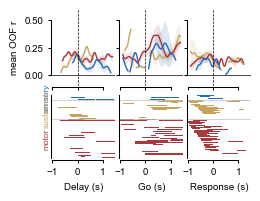

In [4]:
def _smooth_segments(values, sigma):
    values = np.asarray(values, dtype=float)
    if sigma is None or float(sigma) <= 0:
        return values
    out = np.full_like(values, np.nan)
    finite = np.isfinite(values)
    if not finite.any():
        return out
    padded = np.concatenate([[False], finite, [False]])
    edges = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(edges == 1)
    stops = np.flatnonzero(edges == -1)
    for start, stop in zip(starts, stops):
        segment = values[start:stop]
        if segment.size == 1:
            out[start:stop] = segment
        else:
            out[start:stop] = gaussian_filter1d(
                segment, sigma=float(sigma), mode="nearest"
            )
    return out


def _style_rt_ax(ax):
    ax.set_yticks([])
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)


def _sig_matrix(plot_cl, n_rows, phase, xlim):
    times = np.arange(xlim[0], xlim[1] + 1e-12, DT)
    mask = np.zeros((n_rows, times.size), dtype=bool)
    sub = plot_cl.loc[plot_cl.phase == phase]
    for row in sub.itertuples(index=False):
        y = int(row.y)
        if y < 0 or y >= n_rows:
            continue
        start = float(row.start_time)
        end = float(row.end_time)
        mask[y] |= (times >= start) & (times <= end)
    return times, mask


def _rgba_mask(mask, cluster_names):
    rgba = np.zeros(mask.shape + (4,), dtype=float)
    for index, cluster in enumerate(cluster_names):
        color = to_rgba(FUNCTION_COLORS.get(str(cluster), "0.55"))
        rgba[index, mask[index]] = color
    return rgba


def assigned_hit_rows(clusters_df, hit_keys_df):
    assigned = clusters_df[
        clusters_df.functional_cluster.isin(RASTER_CLUSTER_ORDER)
    ].copy()
    hit_assigned = hit_keys_df.merge(
        assigned.drop_duplicates(["task", "subject", "channel"])[
            ["task", "subject", "channel", "functional_cluster"]
        ],
        on=["task", "subject", "channel"],
    )
    hit_assigned = hit_assigned[
        hit_assigned.functional_cluster.isin(RASTER_CLUSTER_ORDER)
    ]
    onset = (
        assigned.merge(
            hit_assigned[["task", "subject", "channel"]],
            on=["task", "subject", "channel"],
        )
        .loc[lambda frame: frame.in_hit_window]
        .groupby(["task", "subject", "channel"], as_index=False)
        .agg(
            functional_cluster=("functional_cluster", "first"),
            sort_time=("start_time", "min"),
        )
    )
    onset["cluster_rank"] = onset["functional_cluster"].map(
        {name: index for index, name in enumerate(RASTER_CLUSTER_ORDER)}
    )
    rows = (
        onset.sort_values(["cluster_rank", "sort_time", "task", "channel"])
        .reset_index(drop=True)
        .assign(y=lambda frame: np.arange(len(frame)))
    )
    plot_cl = assigned.merge(
        rows[["task", "subject", "channel", "y"]],
        on=["task", "subject", "channel"],
    )
    return rows, plot_cl


def load_raster_r(rt_root, rows):
    """OOF r(t) for raster electrodes; non-significant windows are NaN."""
    if rows is None or len(rows) == 0:
        return pd.DataFrame(
            columns=[
                "task",
                "subject",
                "channel",
                "functional_cluster",
                "phase",
                "time",
                "r",
            ]
        )
    needed = rows[["task", "subject", "channel", "functional_cluster"]].drop_duplicates()
    frames = []
    grouped = needed.groupby(["task", "subject"], sort=False)
    for (task, subject), elec in grouped:
        channel_cluster = dict(
            zip(elec["channel"].astype(str), elec["functional_cluster"])
        )
        wanted = set(channel_cluster)
        for phase in PHASE_ORDER:
            path = phase_output_path(
                rt_root,
                task=task,
                subject=subject,
                phase=phase,
                description=DESCRIPTION,
            )
            if not path.is_file():
                continue
            with h5py.File(path, "r") as h5:
                names = decode_strings(h5["channels/channel"][:])
                score_r = np.asarray(h5["scores/r"][:], dtype=float)
                center = np.asarray(h5["windows/center"][:], dtype=float)
                significant = (
                    np.asarray(h5["inference/sig_mask_fwer"][:], dtype=bool)
                    & np.isfinite(score_r)
                    & (score_r > 0)
                )
            for index, channel in enumerate(names):
                if channel not in wanted:
                    continue
                values = np.where(significant[index], score_r[index], np.nan)
                frames.append(
                    pd.DataFrame(
                        {
                            "task": task,
                            "subject": subject,
                            "channel": channel,
                            "functional_cluster": channel_cluster[channel],
                            "phase": phase,
                            "time": center,
                            "r": values,
                        }
                    )
                )
    if not frames:
        return pd.DataFrame(
            columns=[
                "task",
                "subject",
                "channel",
                "functional_cluster",
                "phase",
                "time",
                "r",
            ]
        )
    return pd.concat(frames, ignore_index=True)


def plot_r_over_raster(clusters_df, hit_keys_df, r_df):
    """Stack mean OOF r(t) above the significance raster (shared time axes)."""
    rows, plot_cl = assigned_hit_rows(clusters_df, hit_keys_df)
    n = len(rows)
    if n == 0:
        raise ValueError("No assigned hit electrodes for the RT raster")
    n_by_cl = rows.groupby("functional_cluster").size()
    n_panel = len(PANELS)

    width = 2 * n_panel * cm
    raster_h = max(2.0, 0.02 * n) * cm
    r_h = 2.4 * cm
    fig = plt.figure(figsize=(width, r_h + raster_h))
    gs = GridSpec(
        2,
        n_panel,
        figure=fig,
        height_ratios=[r_h, raster_h],
        hspace=0.12,
        wspace=0.08,
    )
    axes_r = [fig.add_subplot(gs[0, 0])]
    axes_r += [
        fig.add_subplot(gs[0, i], sharey=axes_r[0]) for i in range(1, n_panel)
    ]
    axes_h = [fig.add_subplot(gs[1, i], sharex=axes_r[i]) for i in range(n_panel)]

    for ax, panel in zip(axes_r, PANELS):
        sub = r_df.loc[r_df.phase == panel["phase"]]
        xlim = panel["xlim"]
        for cluster in CLUSTER_ORDER:
            csub = sub.loc[sub.functional_cluster == cluster]
            if csub.empty:
                continue
            grouped = csub.groupby("time")["r"]
            mean = grouped.mean()
            sem = grouped.sem().fillna(0.0)
            y = _smooth_segments(mean.to_numpy(), SMOOTH_SIGMA)
            e = _smooth_segments(sem.to_numpy(), SMOOTH_SIGMA)
            e = np.where(np.isfinite(y), np.nan_to_num(e, nan=0.0), np.nan)
            ax.plot(
                mean.index,
                y,
                color=FUNCTION_COLORS[cluster],
                lw=1,
                label=(
                    f"{CLUSTER_LABELS[cluster]} "
                    f"(n={int(n_by_cl.get(cluster, 0))})"
                ),
            )
            ax.fill_between(
                mean.index,
                y - e,
                y + e,
                color=FUNCTION_COLORS[cluster],
                alpha=0.15,
                linewidth=0,
            )
        ax.axhline(0, color="k", linewidth=0.5)
        ax.axvline(0, color="0.15", linestyle="--", linewidth=0.7, zorder=6)
        ax.set_xlim(*xlim)
        ax.set_ylim(-0.1, 0.6)
        ax.set_xticks(panel["xticks"])
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        ax.tick_params(labelbottom=False)

    axes_r[0].set_ylabel("mean OOF r", fontsize=fontsize)
    for ax in axes_r[1:]:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")

    for ax, panel in zip(axes_h, PANELS):
        xlim = panel["xlim"]
        times, mask = _sig_matrix(plot_cl, n, panel["phase"], xlim)
        t_edges = np.concatenate([times, [times[-1] + DT]])
        y_edges = np.arange(n + 1) - 0.5
        ax.pcolormesh(
            t_edges,
            y_edges,
            _rgba_mask(mask, rows["functional_cluster"].to_numpy()),
            shading="auto",
            rasterized=True,
        )
        ax.set_xlim(*xlim)
        ax.set_xticks(panel["xticks"])
        ax.set_ylim(n - 0.5, -0.5)
        ax.set_xlabel(panel["xlabel"], fontsize=fontsize)
        _style_rt_ax(ax)
        ax.axvline(0, color="k", linestyle="--", linewidth=0.5, zorder=5)

    for cluster in RASTER_CLUSTER_ORDER:
        ys = rows.loc[rows.functional_cluster == cluster, "y"]
        if ys.empty:
            continue
        y0, y1 = ys.min() - 0.5, ys.max() + 0.5
        for ax in axes_h:
            ax.axhline(y1, color="0.75", linewidth=0.5)
        axes_h[0].text(
            -0.04,
            0.5 * (y0 + y1),
            CLUSTER_LABELS[cluster],
            transform=axes_h[0].get_yaxis_transform(),
            fontsize=fontsize - 1,
            color=FUNCTION_COLORS[cluster],
            va="center",
            ha="right",
            rotation=90,
            clip_on=False,
        )

    fig.subplots_adjust(
        left=0.14, right=0.98, top=0.96, bottom=0.10, wspace=0.08, hspace=0.12
    )
    return fig


hit_keys_raster = (
    clusters.loc[
        clusters.in_hit_window & clusters.phase.isin(["Delay", "Go"]),
        ["task", "subject", "channel"],
    ]
    .drop_duplicates()
)
hit_keys_raster["hit"] = True

raster_rows, _ = assigned_hit_rows(clusters, hit_keys_raster)
r_traces = load_raster_r(RT_ROOT, raster_rows)
print(
    f"raster rows={len(raster_rows)} | r traces={len(r_traces)} | "
    f"by cluster={raster_rows.functional_cluster.value_counts().to_dict()}"
)
fig = plot_r_over_raster(clusters, hit_keys_raster, r_traces)
out = save_svg(fig, IMG_DIR / "fig5_clusters_r_over_raster")
print("Wrote", out)

## HGA–RT encoding (assigned pre-Go hits)

Go-aligned fast/slow HGA in Figure 2 trace style (`sns.lineplot` mean ± 95% CI, dashed zeros, despine). Then encoding $r$ and a typical trial scatter. Negative encoding $r$ means higher window-mean HGA with shorter log RT. Wilcoxon on subject-level $r$ (median across tasks) is the primary descriptive test.


motor: median r=-0.271 | Wilcoxon p=0.01562 | n_elec=10 | example=D0061/PhonemeSequence r=-0.465
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_hga_rt_motor.svg
sustain: median r=-0.106 | Wilcoxon p=0.3125 | n_elec=4 | example=D0084/PictureNaming r=-0.328
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_hga_rt_sustain.svg
sensory: median r=0.295 | Wilcoxon p=nan | n_elec=1 | example=D0085/PictureNaming r=0.295
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_hga_rt_sensory.svg


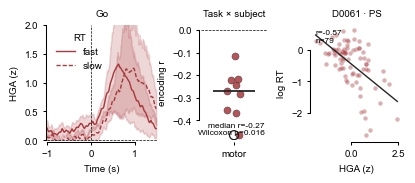

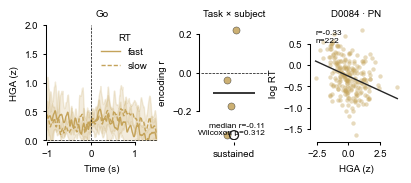

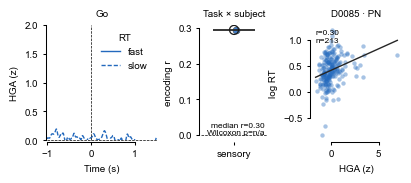

In [5]:
def _style_panel(ax):
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)


def _hga_rt_long(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    long = frame.loc[:, ["task", "subject", "time", "hga_fast", "hga_slow"]].melt(
        id_vars=["task", "subject", "time"],
        value_vars=["hga_fast", "hga_slow"],
        var_name="rt_split",
        value_name="hga",
    )
    long["rt_split"] = long["rt_split"].map({"hga_fast": "fast", "hga_slow": "slow"})
    return long.dropna(subset=["hga", "time"])


def _plot_fast_slow_hga(
    ax,
    frame,
    color,
    *,
    xlim,
    xticks,
    xlabel,
    title,
    ylabel=None,
    legend=False,
    hide_y=False,
    ylim=None,
):
    """Fig 2 HGA-trace style: sns.lineplot, dashed zeros, despine."""
    long = _hga_rt_long(frame)
    if not long.empty:
        sns.lineplot(
            data=long,
            x="time",
            y="hga",
            hue="rt_split",
            hue_order=["fast", "slow"],
            style="rt_split",
            style_order=["fast", "slow"],
            dashes={"fast": "", "slow": (3, 1.4)},
            palette={"fast": color, "slow": color},
            ax=ax,
            lw=1,
            legend=legend,
        )
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xticks(list(xticks))
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if hide_y:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel(ylabel or "", fontsize=fontsize)
    if legend and ax.get_legend() is not None:
        ax.legend(
            title="RT",
            fontsize=fontsize,
            title_fontsize=fontsize,
            frameon=False,
        )
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()


def plot_cluster_hga_rt(cluster: str):
    """Go HGA (Fig 2 style), then encoding r and a typical trial scatter."""
    cl_traces = traces.loc[traces.functional_cluster == cluster].copy()
    cl_enc = subjects_enc.loc[subjects_enc.functional_cluster == cluster].copy()
    cl_trials = trials.loc[trials.functional_cluster == cluster].copy()
    cl_elec = elec_enc.loc[elec_enc.functional_cluster == cluster]
    if cl_enc.empty or cl_traces.empty:
        print(f"skip {cluster}: no assigned pre-Go encoding rows")
        return None

    color = FUNCTION_COLORS[cluster]
    label = CLUSTER_LABELS[cluster]
    n_elec = int(cl_elec.drop_duplicates(["subject", "channel"]).shape[0])

    typical = cl_enc.loc[cl_enc["mean_hga_log_rt_r"].idxmin()]
    typical_task = str(typical["task"])
    typical_subject = str(typical["subject"])
    typical_r = float(typical["mean_hga_log_rt_r"])
    group_med = float(cl_enc["mean_hga_log_rt_r"].median())

    subj_r = (
        cl_enc.groupby("subject")["mean_hga_log_rt_r"]
        .median()
        .to_numpy(dtype=float)
    )
    subj_r = subj_r[np.isfinite(subj_r)]
    if len(subj_r) >= 2 and not np.allclose(subj_r, 0.0):
        wilcoxon_p = float(wilcoxon(subj_r, alternative="less").pvalue)
    else:
        wilcoxon_p = np.nan

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(10 * cm, 4.2 * cm),
        gridspec_kw=dict(width_ratios=[1.4, 0.85, 1.15], wspace=0.5),
    )
    ax_g, ax_m, ax_r = axes

    _plot_fast_slow_hga(
        ax_g,
        cl_traces,
        color,
        xlim=GO_XLIM,
        xticks=HGA_XTICKS,
        xlabel="Time (s)",
        title="Go",
        ylabel="HGA (z)",
        legend=True,
        ylim=HGA_YLIM,
    )

    rng = np.random.default_rng(0)
    vals = cl_enc["mean_hga_log_rt_r"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    jitter = rng.uniform(-0.08, 0.08, size=vals.size)
    ax_m.scatter(
        jitter,
        vals,
        s=26,
        c=color,
        marker="o",
        alpha=0.85,
        linewidths=0.35,
        edgecolors="0.2",
        zorder=3,
    )
    ax_m.scatter(
        [0.0],
        [typical_r],
        s=42,
        facecolors="none",
        edgecolors="0.1",
        linewidths=0.9,
        marker="o",
        zorder=5,
    )
    ax_m.axhline(0, color="k", linestyle="--", linewidth=0.5)
    ax_m.hlines(group_med, -0.22, 0.22, colors="0.15", lw=1.3, zorder=4)
    ax_m.set_xlim(-0.35, 0.35)
    ax_m.set_xticks([0])
    ax_m.set_xticklabels([label], fontsize=fontsize)
    ax_m.set_ylabel("encoding r", fontsize=fontsize)
    ax_m.set_title("Task × subject", fontsize=fontsize)
    _style_panel(ax_m)
    p_txt = f"{wilcoxon_p:.3f}" if np.isfinite(wilcoxon_p) else "n/a"
    ax_m.text(
        0.96,
        0.04,
        f"median r={group_med:.2f}\nWilcoxon p={p_txt}",
        transform=ax_m.transAxes,
        ha="right",
        va="bottom",
        fontsize=fontsize - 1,
        linespacing=1.35,
    )

    ex = cl_trials.loc[
        (cl_trials.subject == typical_subject) & (cl_trials.task == typical_task)
    ].copy()
    keep = np.isfinite(ex["hga_z"]) & np.isfinite(ex["rt_log"])
    ex = ex.loc[keep]
    x = ex["hga_z"].to_numpy(dtype=float)
    y = ex["rt_log"].to_numpy(dtype=float)
    ax_r.scatter(
        x,
        y,
        s=10,
        c=color,
        marker="o",
        alpha=0.4,
        linewidths=0,
        zorder=2,
    )
    if len(ex) >= 3 and np.std(x) > 0 and np.std(y) > 0:
        r_val, _ = pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
        ax_r.plot(x_line, slope * x_line + intercept, color="0.15", lw=1.0, zorder=3)
    else:
        r_val = typical_r
    ax_r.set_xlabel("HGA (z)", fontsize=fontsize)
    ax_r.set_ylabel("log RT", fontsize=fontsize)
    ax_r.set_title(
        f"{typical_subject} · {TASK_SHORT[typical_task]}",
        fontsize=fontsize,
    )
    _style_panel(ax_r)
    ax_r.text(
        0.04,
        0.96,
        f"r={r_val:.2f}\nn={len(ex)}",
        transform=ax_r.transAxes,
        ha="left",
        va="top",
        fontsize=fontsize - 1,
        linespacing=1.35,
    )

    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.88, wspace=0.5)
    out = save_svg(fig, IMG_DIR / f"fig5_hga_rt_{cluster}")
    print(
        f"{cluster}: median r={group_med:.3f} | "
        f"Wilcoxon p={wilcoxon_p:.4g} | "
        f"n_elec={n_elec} | "
        f"example={typical_subject}/{typical_task} r={typical_r:.3f}"
    )
    print("Wrote", out)
    return fig


for _cluster in ENCODING_CLUSTERS:
    plot_cluster_hga_rt(_cluster)


## Population encoding null

One-sample $t$ of subject-median encoding $r$ (HGA vs log RT). Null shuffles `rt_log` within each task × subject; one KDE per cluster on the same axis. Windows stay fixed, so this is still post-selection. Left tail: higher HGA with shorter RT. Sensory has one subject, so $t$ is undefined and has no null.

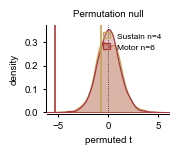

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_encoding_perm_null.svg
sensory n_subj=1  t=nan  median r=0.295  p_left=nan  n_perm=5000
sustain n_subj=4  t=-0.68  median r=-0.106  p_left=0.3011  n_perm=5000
motor n_subj=6  t=-5.27  median r=-0.309  p_left=0.0014  n_perm=5000


In [6]:
from IPython.display import display

from src.reaction_time.summarize_insula_rt_encoding import (
    permute_subject_encoding_t,
)

N_PERM_ENC = 5000
PERM_CLUSTER_ORDER = ("sensory", "sustain", "motor")
enc_nulls = {}
for cluster in PERM_CLUSTER_ORDER:
    cluster_trials = trials.loc[trials.functional_cluster == cluster].copy()
    enc_nulls[cluster] = permute_subject_encoding_t(
        cluster_trials, n_perm=N_PERM_ENC, random_state=42
    )

halves = []
for cluster, enc_null in enc_nulls.items():
    obs_t = float(enc_null["observed_t"])
    finite_null = np.asarray(enc_null["null_t"], dtype=float)
    finite_null = finite_null[np.isfinite(finite_null)]
    if np.isfinite(obs_t):
        halves.append(abs(obs_t))
    if finite_null.size:
        halves.append(float(np.percentile(np.abs(finite_null), 99)))
half = max(halves) if halves else 5.0
pad = 0.15 * half
xlim = (-half - pad, half + pad)

fig, ax = plt.subplots(figsize=(4.8 * cm, 4.2 * cm))
for cluster in PERM_CLUSTER_ORDER:
    enc_null = enc_nulls[cluster]
    color = FUNCTION_COLORS[cluster]
    finite_null = np.asarray(enc_null["null_t"], dtype=float)
    finite_null = finite_null[np.isfinite(finite_null)]
    n_subj = int(enc_null["n_subjects"])
    if not finite_null.size:
        continue
    sns.kdeplot(
        finite_null,
        ax=ax,
        color=color,
        fill=True,
        alpha=0.28,
        linewidth=0.9,
        clip=xlim,
        label=f"{cluster.capitalize()} n={n_subj}",
        zorder=1,
    )
ax.axvline(0, color="k", linestyle=":", lw=0.5, zorder=2)
for cluster in PERM_CLUSTER_ORDER:
    enc_null = enc_nulls[cluster]
    obs_t = float(enc_null["observed_t"])
    if np.isfinite(obs_t):
        ax.axvline(obs_t, color=FUNCTION_COLORS[cluster], lw=1.2, zorder=3)
ax.set_xlim(*xlim)
ax.set_xlabel("permuted t", fontsize=fontsize)
ax.set_ylabel("density", fontsize=fontsize)
ax.set_title("Permutation null", fontsize=fontsize)
ax.legend(frameon=False, fontsize=fontsize - 1, loc="upper right", handlelength=0.9)
ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
plt.setp(ax.spines.values(), linewidth=0.75)
sns.despine(ax=ax, offset=1, trim=False)
fig.tight_layout()
out = save_svg(fig, IMG_DIR / "fig5_encoding_perm_null")
display(fig)
plt.close(fig)
print("Wrote", out)
for cluster in PERM_CLUSTER_ORDER:
    enc_null = enc_nulls[cluster]
    obs_t = float(enc_null["observed_t"])
    observed_r = np.asarray(enc_null["observed_r"], dtype=float)
    median_r = float(np.median(observed_r)) if observed_r.size else np.nan
    print(
        f"{cluster} n_subj={enc_null['n_subjects']}  "
        f"t={obs_t:.2f}  median r={median_r:.3f}  "
        f"p_left={enc_null['p_left']:.4g}  n_perm={enc_null['n_perm']}"
    )


## Hit electrodes (insula)

Assigned NMF contacts with a Delay / pre-Go / pre-Response RT hit. Same insula mesh, superior view, and crop as Figure 4. Unassigned hits are counted in the printout but not drawn.


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
plotting assigned RT-hit electrodes: 56 | L 35 R 21 | unique hits=86 unassigned hits=30


2026-09-16 13:14:31.257 (   2.005s) [    7F83D8A10740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_rt_hit_electrodes.svg
functional_cluster
sensory     5
sustain    17
motor      34


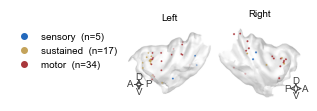

In [7]:
import os
import warnings

import mne
import pyvista as pv
from matplotlib.lines import Line2D
from mne.viz import Brain
from scipy.spatial import cKDTree

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
template = "cvs_avg35_inMNI152"
insula_patterns = (
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
)
POINT_SIZE = 13.0
CROP_PAD_PX = 24
INSULA_COLOR = (0.9, 0.9, 0.9)
INSULA_LABEL_ALPHA = 0.55

labels = mne.read_labels_from_annot(
    subject=template,
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
lh_pial_coords, lh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/lh.pial")
rh_pial_coords, rh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_vertices(hemi: str) -> np.ndarray:
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f"No insula labels for {hemi}")
    return np.unique(verts)


def _faces_to_polydata(coords, faces) -> pv.PolyData:
    faces_pv = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), np.asarray(faces, dtype=np.int64)]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def insula_mesh(hemi: str, pial: np.ndarray, faces: np.ndarray):
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    mesh = _faces_to_polydata(pial, faces[keep])
    center = pial[verts].mean(axis=0)
    return mesh, center


lh_insula, lh_insula_center = insula_mesh("lh", lh_pial_coords, lh_faces)
rh_insula, rh_insula_center = insula_mesh("rh", rh_pial_coords, rh_faces)


def snap_to_pial(coords, tree, pial):
    _, idx = tree.query(coords)
    return pial[idx]


def add_cluster_spheres(brain, coords, clusters, tree, pial):
    coords = np.asarray(coords, dtype=float)
    if coords.size == 0:
        return np.zeros((0, 3), dtype=float)
    snapped = snap_to_pial(coords, tree, pial)
    for cluster in RASTER_CLUSTER_ORDER:
        mask = np.asarray(clusters) == cluster
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(snapped[mask], dtype=float))
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=POINT_SIZE,
            color=FUNCTION_COLORS[cluster],
            lighting=False,
        )
    return snapped


def project_xy(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if hasattr(plotter, "project_points_to_pixels"):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    h = int(image_shape[0])
    xy[:, 1] = (h - 1) - xy[:, 1]
    return xy


def draw_ap_dv(ax, *, anterior_is_left: bool, corner: str):
    if corner == "lower left":
        x0, y0, arm = 0.16, 0.18, 0.08
    else:
        x0, y0, arm = 0.91, 0.16, 0.07
    gap = 0.012
    if anterior_is_left:
        tips = {"A": (x0 - arm, y0), "P": (x0 + arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    else:
        tips = {"A": (x0 + arm, y0), "P": (x0 - arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    for label, (tx, ty) in tips.items():
        sx = x0 + gap * np.sign(tx - x0) if tx != x0 else x0
        sy = y0 + gap * np.sign(ty - y0) if ty != y0 else y0
        ax.annotate(
            "",
            xy=(tx, ty),
            xytext=(sx, sy),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="0.25", lw=0.7, mutation_scale=7),
            annotation_clip=False,
        )
        px = 0.03 * np.sign(tx - x0) if tx != x0 else 0.0
        py = 0.035 * np.sign(ty - y0) if ty != y0 else 0.0
        ax.text(
            tx + px,
            ty + py,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="0.25",
            clip_on=False,
        )


def crop_to_content(img, xy, pad=CROP_PAD_PX):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float)
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    return rgb[y0:y1, x0:x1], xy_c


def render_hemi(hemi: str, coords, clusters):
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=INSULA_COLOR,
        alpha=0.0,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    mesh = lh_insula if hemi == "lh" else rh_insula
    plotter.add_mesh(
        mesh,
        color=INSULA_COLOR,
        opacity=INSULA_LABEL_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    tree = lh_tree if hemi == "lh" else rh_tree
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    snapped = add_cluster_spheres(brain, coords, clusters, tree, pial)
    center = lh_insula_center if hemi == "lh" else rh_insula_center
    az = 180 if hemi == "lh" else 0
    brain.show_view(azimuth=az, elevation=90, distance=180, focalpoint=center)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    xy = project_xy(plotter, snapped, img.shape[:2])
    brain.close()
    return img, xy


hit_unique = hit_keys.drop_duplicates(["subject", "channel"])[["subject", "channel"]]
elec_unique = electrodes.drop_duplicates(["subject", "channel"]).copy()
n_hit_all = int(len(hit_unique))
hit_meta = elec_unique.merge(hit_unique, on=["subject", "channel"], how="inner")
n_unassigned = int((~hit_meta.functional_cluster.isin(RASTER_CLUSTER_ORDER)).sum())

spatial = elec_unique.merge(
    hit_unique[["subject", "channel"]], on=["subject", "channel"], how="inner"
)
spatial["x"] = spatial["x_template"]
spatial["y"] = spatial["y_template"]
spatial["z"] = spatial["z_template"]
spatial = spatial.loc[
    spatial["functional_cluster"].isin(RASTER_CLUSTER_ORDER)
    & spatial[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0
print(
    "plotting assigned RT-hit electrodes:",
    spatial.channel.nunique() if len(spatial) else 0,
    "| L",
    int(mask_lh.sum()),
    "R",
    int(mask_rh.sum()),
    f"| unique hits={n_hit_all} unassigned hits={n_unassigned}",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img, lh_xy = render_hemi("lh", cord[mask_lh], clust[mask_lh])
    rh_img, rh_xy = render_hemi("rh", cord[mask_rh], clust[mask_rh])

lh_img, lh_xy = crop_to_content(lh_img, lh_xy)
rh_img, rh_xy = crop_to_content(rh_img, rh_xy)

fig, axes = plt.subplots(1, 2, figsize=(6.5 * cm, 3.0 * cm))
for ax, img, title in (
    (axes[0], lh_img, "Left"),
    (axes[1], rh_img, "Right"),
):
    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)
    if title == "Left":
        draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
    else:
        draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

n_by_cluster = spatial.groupby("functional_cluster")["channel"].nunique()
axes[0].legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=FUNCTION_COLORS[c],
            markeredgecolor=FUNCTION_COLORS[c],
            markersize=4,
            label=f"{CLUSTER_LABELS[c]}  (n={int(n_by_cluster.get(c, 0))})",
        )
        for c in RASTER_CLUSTER_ORDER
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
    bbox_to_anchor=(-0.04, 1.0),
    borderaxespad=0.0,
)
fig.subplots_adjust(wspace=0.02, left=0.28, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig5_rt_hit_electrodes")
print("Wrote", out)
print(n_by_cluster.reindex(RASTER_CLUSTER_ORDER).to_string())


## Hit electrodes (Delay + Go only)

Same insula render as the previous panel, but hits are only Delay (`end_time > 0`) or pre-Go (`start_time < 0`). Pre-Response windows are dropped. Reuses `render_hemi` from the cell above.


plotting assigned Delay+Go RT-hit electrodes: 27 | L 13 R 14 | unique hits=39 unassigned hits=12


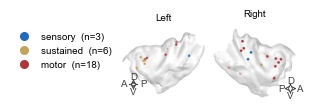

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig5/fig5_rt_hit_electrodes_delay_go.svg
functional_cluster
sensory     3
sustain     6
motor      18


In [9]:
from IPython.display import display

POINT_SIZE = 18.0

hit_keys_delay_go = (
    clusters.loc[
        clusters.in_hit_window & clusters.phase.isin(["Delay", "Go"]),
        ["task", "subject", "channel"],
    ]
    .drop_duplicates()
)
hit_keys_delay_go["hit"] = True

hit_unique = hit_keys_delay_go.drop_duplicates(["subject", "channel"])[
    ["subject", "channel"]
]
elec_unique = electrodes.drop_duplicates(["subject", "channel"]).copy()
n_hit_all = int(len(hit_unique))
hit_meta = elec_unique.merge(hit_unique, on=["subject", "channel"], how="inner")
n_unassigned = int((~hit_meta.functional_cluster.isin(RASTER_CLUSTER_ORDER)).sum())

spatial = elec_unique.merge(
    hit_unique[["subject", "channel"]], on=["subject", "channel"], how="inner"
)
spatial["x"] = spatial["x_template"]
spatial["y"] = spatial["y_template"]
spatial["z"] = spatial["z_template"]
spatial = spatial.loc[
    spatial["functional_cluster"].isin(RASTER_CLUSTER_ORDER)
    & spatial[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0
print(
    "plotting assigned Delay+Go RT-hit electrodes:",
    spatial.channel.nunique() if len(spatial) else 0,
    "| L",
    int(mask_lh.sum()),
    "R",
    int(mask_rh.sum()),
    f"| unique hits={n_hit_all} unassigned hits={n_unassigned}",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img, lh_xy = render_hemi("lh", cord[mask_lh], clust[mask_lh])
    rh_img, rh_xy = render_hemi("rh", cord[mask_rh], clust[mask_rh])

lh_img, lh_xy = crop_to_content(lh_img, lh_xy)
rh_img, rh_xy = crop_to_content(rh_img, rh_xy)

fig, axes = plt.subplots(1, 2, figsize=(6.5 * cm, 3.0 * cm))
for ax, img, title in (
    (axes[0], lh_img, "Left"),
    (axes[1], rh_img, "Right"),
):
    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)
    if title == "Left":
        draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
    else:
        draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

n_by_cluster = spatial.groupby("functional_cluster")["channel"].nunique()
axes[0].legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=FUNCTION_COLORS[c],
            markeredgecolor=FUNCTION_COLORS[c],
            markersize=5.5,
            label=f"{CLUSTER_LABELS[c]}  (n={int(n_by_cluster.get(c, 0))})",
        )
        for c in RASTER_CLUSTER_ORDER
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
    bbox_to_anchor=(-0.04, 1.0),
    borderaxespad=0.0,
)
fig.subplots_adjust(wspace=0.02, left=0.28, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig5_rt_hit_electrodes_delay_go")
display(fig)
plt.close(fig)
print("Wrote", out)
print(n_by_cluster.reindex(RASTER_CLUSTER_ORDER).to_string())
